In [1]:
import torch
import torch.multiprocessing as mp
from gymnasium.vector import AsyncVectorEnv
import numpy as np
from env import mbb
from models import ppo
import os
import pandas as pd
import matplotlib.pyplot as plt
import logging
from datetime import datetime
import random
from torch import amp
from env import mbb_cnn
from models import ppo_cnn


In [2]:

# Configure logging
logging.basicConfig(
    level=logging.INFO,  # Set to DEBUG for more detailed logs
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("reward_logs.log"),  # Log to a file
        logging.StreamHandler()  # Also log to console
    ]
)


print("============================================================================================")
device = torch.device('cpu')
if(torch.cuda.is_available()): 
    device = torch.device('cuda:0') 
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")  
print("============================================================================================")


Device set to : NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
!nvidia-smi

Sun Mar 30 18:27:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8              4W /   80W |      12MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Vector Environment Type: <class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
Action dimension: 72
Started training at (GMT): 2025-03-30 18:27:55
Current logging run number for BeamOptimizationEnv: 5
Logging at: PPO_logs/BeamOptimizationEnv/PPO_BeamOptimizationEnv_log_5.csv
Save checkpoint path: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth


/home/mihovil/mihovil/structural_optimization/structural_optimization/src/models/ppo_cnn.py:231: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  states = torch.tensor(states, dtype=torch.float32, device=self.device)
/tmp/ipykernel_8575/1776487002.py:125: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logprobs=torch.tensor(logprobs, dtype=torch.float32, device=ppo_agent.device),
/tmp/ipykernel_8575/1776487002.py:127: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_values=torch.tensor(state_values, dtype=torch.float32, device=ppo_agent.dev

Episode: 1 	 Timestep: 144 	 Average Reward: -772.74
Episode: 3 	 Timestep: 288 	 Average Reward: -743.01
Episode: 5 	 Timestep: 432 	 Average Reward: -731.79
Episode: 7 	 Timestep: 576 	 Average Reward: -679.56
Episode: 9 	 Timestep: 720 	 Average Reward: -684.35
Episode: 11 	 Timestep: 864 	 Average Reward: -693.97
--------------------------------------------------------------------------------------------
Saving model at PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
Model saved.
Elapsed Time: 0:00:08
--------------------------------------------------------------------------------------------
Episode: 13 	 Timestep: 1008 	 Average Reward: -659.8
Episode: 15 	 Timestep: 1152 	 Average Reward: -664.22
Episode: 17 	 Timestep: 1296 	 Average Reward: -623.73
Episode: 19 	 Timestep: 1440 	 Average Reward: -664.81
Episode: 21 	 Timestep: 1584 	 Average Reward: -648.88
Episode: 23 	 Timestep: 1728 	 Average Reward: -621.71
Episode: 25 	 Timestep: 1872 	 Average Reward: -

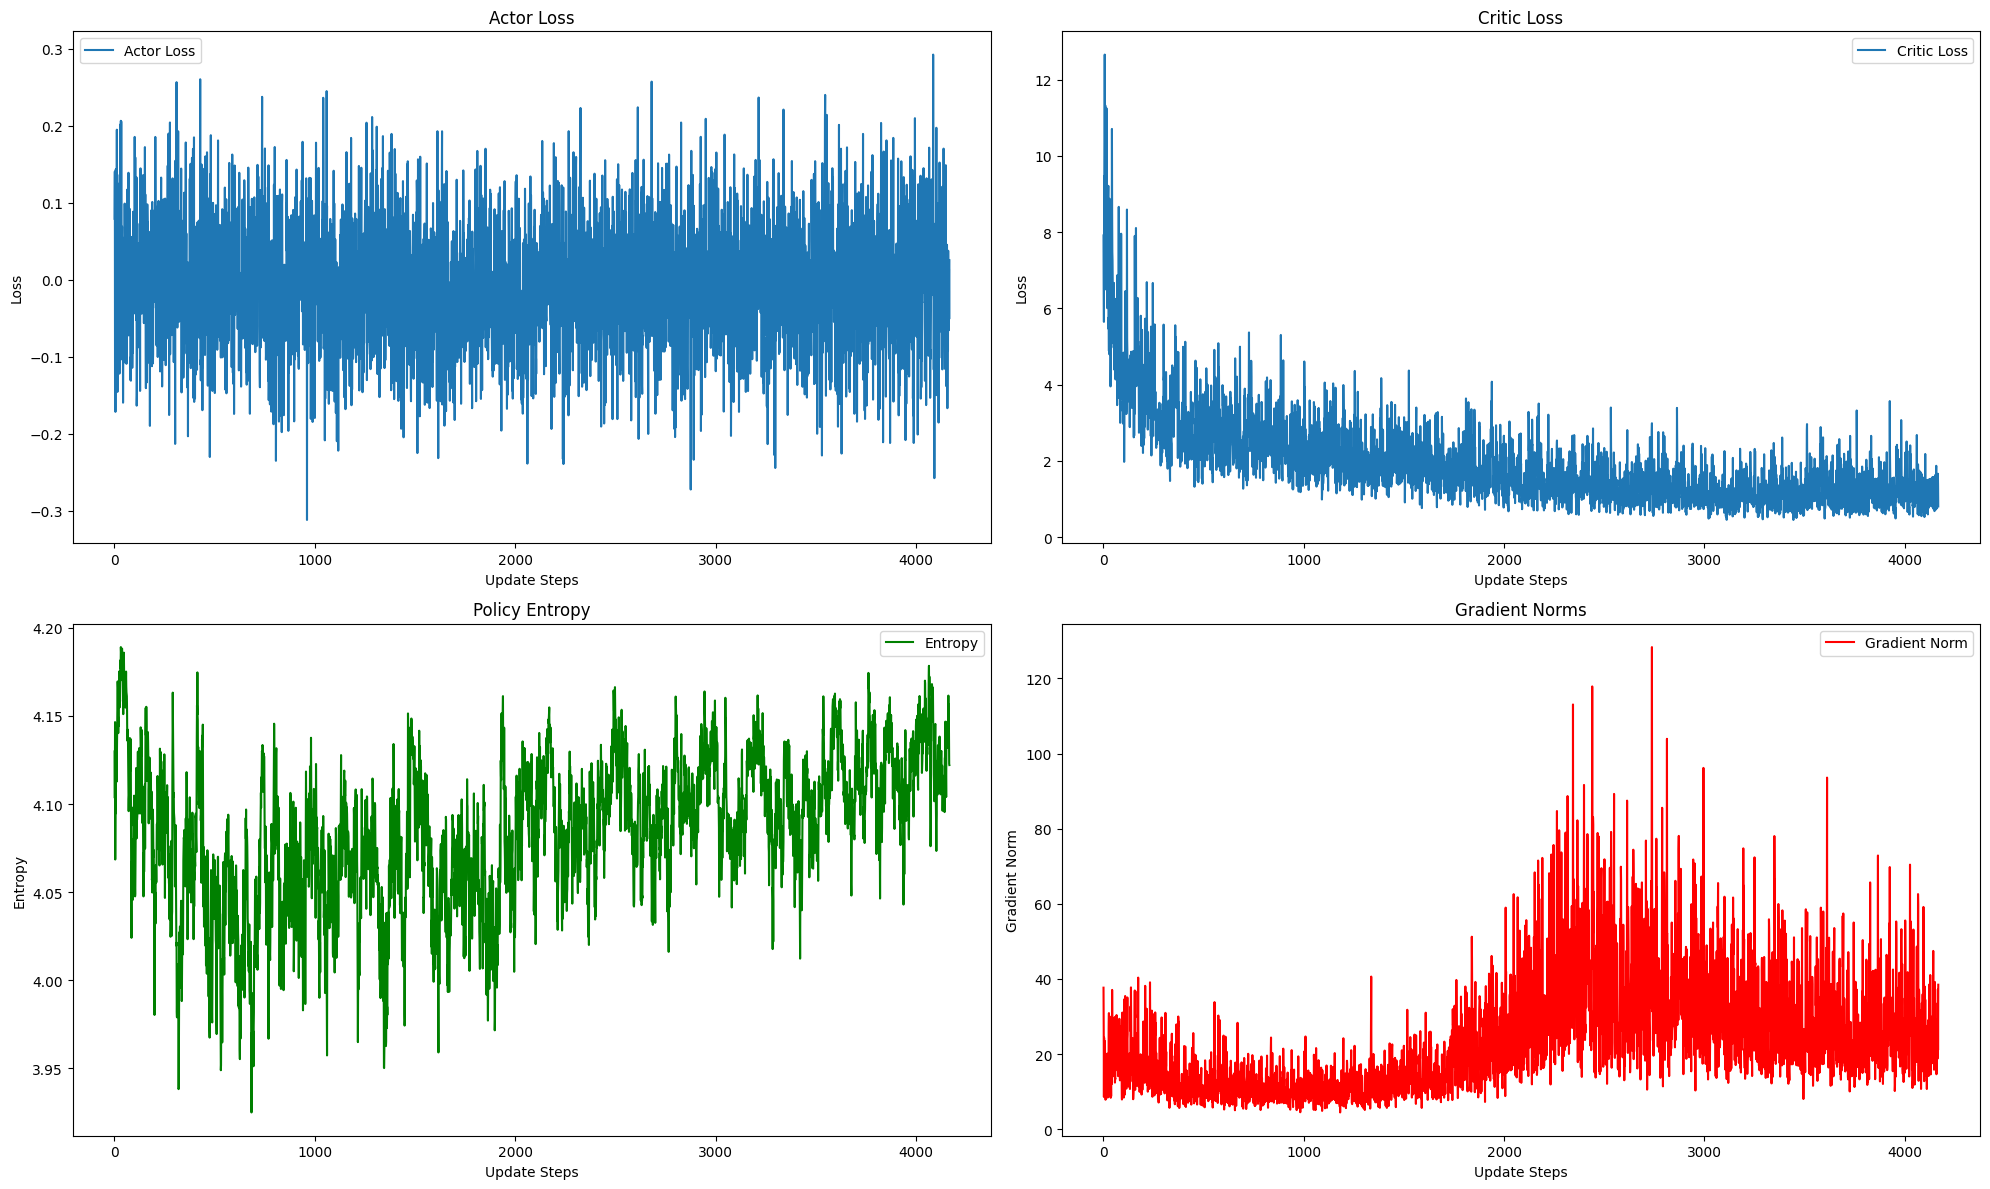

Dataset saved at: dataset/beam_compliance_dataset_20250330_182755.npz


In [4]:

def make_beam_env():
    beam_type = random.choice([1, 2, 3, 4, 6, 7, 8, 9])
    # beam_type = random.choice([1,5])
    #beam_type = 1  # Fixed for now
    return mbb_cnn.BeamOptimizationEnv(
        width=6, height=6, density=0.4, optimal_density=0.5,
        reward_weights=None, beam_type=beam_type
    )

if __name__ == "__main__":
    # Use spawn for multiprocessing with vectorized envs.
    mp.set_start_method('spawn', force=True)
    
    # Set random seeds for reproducibility.
    random_seed = 0
    random.seed(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    # Hyperparameters.
    env_name = "BeamOptimizationEnv"
    num_envs = 16
    width = 6
    height = 6
    # The environment returns a 5-channel image of shape (5, width+1, height+1) i.e. (5, 7, 7).
    grid_channels = 5
    grid_height = width + 1   # 7
    grid_width = height + 1   # 7
    state_dim = grid_channels * grid_height * grid_width  # 245
    action_dim = 2 * width * height  # 72 (Discrete actions)
    has_continuous_action_space = False
    max_ep_len = width * height * 2
    max_training_timesteps = int(1e5)
    update_timestep = max_ep_len  # Update PPO once per episode.

    # Continuous action decay parameters (if needed)
    action_std_decay_freq = 5000
    action_std_decay_rate = 0.05
    min_action_std = 0.1

    # Create vectorized environments.
    env_fns = [make_beam_env for _ in range(num_envs)]
    vector_env = AsyncVectorEnv(env_fns)
    print(f"Vector Environment Type: {type(vector_env)}")
    action_dim = vector_env.single_action_space.n
    print(f"Action dimension: {action_dim}")

    # Initialize PPO agent with the CNN-based network.
    ppo_agent = ppo_cnn.PPO(
        state_dim=state_dim,
        action_dim=action_dim,
        lr_actor=0.0003,
        lr_critic=0.001,
        gamma=0.95,
        K_epochs=3,
        eps_clip=0.3,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=0.6,
        gae_lambda=0.95,
        num_envs=num_envs,
        device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
        grid_channels=grid_channels,
        grid_height=grid_height,
        grid_width=grid_width
    )

    start_time = datetime.now().replace(microsecond=0)
    print("Started training at (GMT):", start_time)
    print("=" * 100)

    # Logging and checkpoint setup.
    log_dir = os.path.join("PPO_logs", env_name)
    os.makedirs(log_dir, exist_ok=True)
    run_num = len([name for name in os.listdir(log_dir) if os.path.isfile(os.path.join(log_dir, name))])
    log_f_name = os.path.join(log_dir, f'PPO_{env_name}_log_{run_num}.csv')
    print(f"Current logging run number for {env_name}: {run_num}")
    print(f"Logging at: {log_f_name}")

    checkpoint_dir = os.path.join("PPO_preTrained", env_name)
    os.makedirs(checkpoint_dir, exist_ok=True)
    run_num_pretrained = 0
    checkpoint_path = os.path.join(checkpoint_dir, f"PPO_{env_name}_{random_seed}_{run_num_pretrained}.pth")
    print(f"Save checkpoint path: {checkpoint_path}")

    with open(log_f_name, "w+") as log_f:
        log_f.write("episode,timestep,average_reward\n")

    print_running_reward = 0
    log_running_reward = 0
    print_running_episodes = 0
    log_running_episodes = 0
    timestep = 0
    i_episode = 0

    # Prepare lists to collect dataset of (state, compliance) pairs.
    dataset_states = []       # Each state will be stored as a numpy array of shape (5, 7, 7)
    dataset_compliances = []  # Compliance values (scalars)

    while timestep < max_training_timesteps:
        # Reset all environments.
        states, infos = vector_env.reset()
        # The environment returns states with shape [num_envs, 5, 7, 7]. Flatten to [num_envs, 245] for PPO.
        states_tensor = torch.tensor(states, dtype=torch.float32, device=ppo_agent.device)
        states_flat = states_tensor.view(states_tensor.size(0), -1)
        ep_rewards = np.zeros(num_envs)
        
        for t_step in range(1, max_ep_len + 1):
            actions, logprobs, state_values = ppo_agent.select_action(states_flat)
            try:
                next_states, rewards, dones, truncateds, infos = vector_env.step(actions)
            except Exception as e:
                print(f"Error during environment step: {e}")
                break
            # Combine done and truncated flags.
            dones_combined = np.logical_or(dones, truncateds)
            next_states_tensor = torch.tensor(next_states, dtype=torch.float32, device=ppo_agent.device)
            states_flat = next_states_tensor.view(next_states_tensor.size(0), -1)
            if not ppo_agent.has_continuous_action_space:
                actions_tensor = torch.LongTensor(actions).to(ppo_agent.device)
            else:
                actions_tensor = torch.FloatTensor(actions).to(ppo_agent.device)
            ppo_agent.buffer.store(
                states=states_flat,
                actions=actions_tensor,
                logprobs=torch.tensor(logprobs, dtype=torch.float32, device=ppo_agent.device),
                rewards=torch.tensor(rewards, dtype=torch.float32, device=ppo_agent.device),
                state_values=torch.tensor(state_values, dtype=torch.float32, device=ppo_agent.device),
                is_terminals=torch.tensor(dones_combined, dtype=torch.bool, device=ppo_agent.device)
            )
            ep_rewards += rewards
            timestep += 1

            # --- Dataset Collection ---
            # Here, for each environment we extract the state (as a 5x7x7 numpy array)
            # and the compliance value from infos (using key 'compliance_after').
            # You may choose to log the state before or after the action; here we log the state
            # that was returned from the step (i.e., next_states) along with its compliance.
            state_np = next_states.copy()
            compliance = infos['compliance_after']

            for env_idx in range(num_envs):
                # Ensure you get a copy of the state data
                state_np = next_states[env_idx].copy()  
                # Extract compliance from the info dictionary; change key as needed.
                compliance = infos['compliance_after'][env_idx]
                compliance = np.log(1 + compliance)
                dataset_states.append(state_np)
                dataset_compliances.append(compliance)
            # --------------------------------

            if timestep % update_timestep == 0:
                ppo_agent.update()

            if ppo_agent.has_continuous_action_space and timestep % action_std_decay_freq == 0:
                ppo_agent.decay_action_std(action_std_decay_rate, min_action_std)

            if timestep % update_timestep == 0:
                avg_reward = log_running_reward / log_running_episodes if log_running_episodes > 0 else 0
                avg_reward = round(np.mean(avg_reward), 4) if isinstance(avg_reward, np.ndarray) else round(avg_reward, 4)
                with open(log_f_name, "a") as log_f:
                    log_f.write(f"{i_episode},{timestep},{avg_reward}\n")
                log_running_reward = 0
                log_running_episodes = 0

            if timestep % (update_timestep * 2) == 0:
                avg_reward = print_running_reward / print_running_episodes if print_running_episodes > 0 else 0
                avg_reward = round(np.mean(avg_reward), 2) if isinstance(avg_reward, np.ndarray) else round(avg_reward, 2)
                print(f"Episode: {i_episode} \t Timestep: {timestep} \t Average Reward: {avg_reward}")
                print_running_reward = 0
                print_running_episodes = 0

            if timestep % 1000 == 0:
                print("-" * 92)
                print(f"Saving model at {checkpoint_path}")
                ppo_agent.save(checkpoint_path)
                print("Model saved.")
                elapsed_time = datetime.now().replace(microsecond=0) - start_time
                print(f"Elapsed Time: {elapsed_time}")
                print("-" * 92)

            if dones_combined.all():
                break

        print_running_reward += ep_rewards.sum()
        print_running_episodes += 1
        log_running_reward += ep_rewards.sum()
        log_running_episodes += 1
        i_episode += 1

    vector_env.close()
    end_time = datetime.now().replace(microsecond=0)
    print("=" * 92)
    print("Started training at (GMT):", start_time)
    print("Finished training at (GMT):", end_time)
    print(f"Total training time: {end_time - start_time}")
    print("=" * 92)
    ppo_agent.plot_metrics()

    # Save the collected dataset.
    dataset_save_path = os.path.join("dataset", f"beam_compliance_dataset_{start_time.strftime('%Y%m%d_%H%M%S')}.npz")
    os.makedirs(os.path.dirname(dataset_save_path), exist_ok=True)
    np.savez(dataset_save_path, states=np.array(dataset_states), compliances=np.array(dataset_compliances))
    print(f"Dataset saved at: {dataset_save_path}")


State dim: 245
Action dim: 72
Loading network from: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
--------------------------------------------------------------------------------------------
Episode 1: Compliance: 84.51132295019367 | Constraint: 0.5230510234832764


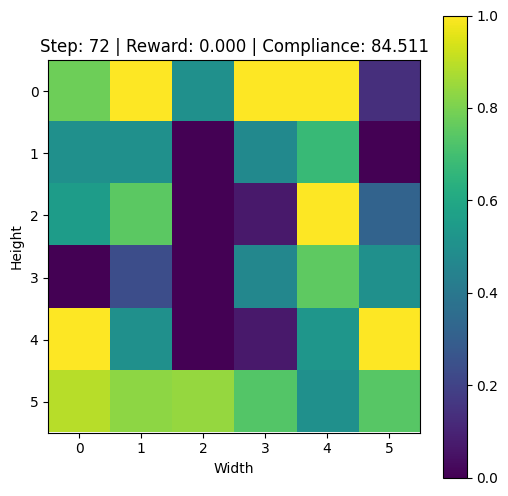

Episode: 1 	 Reward: -23.65
Episode 2: Compliance: 296.4944105851199 | Constraint: 0.5223734974861145


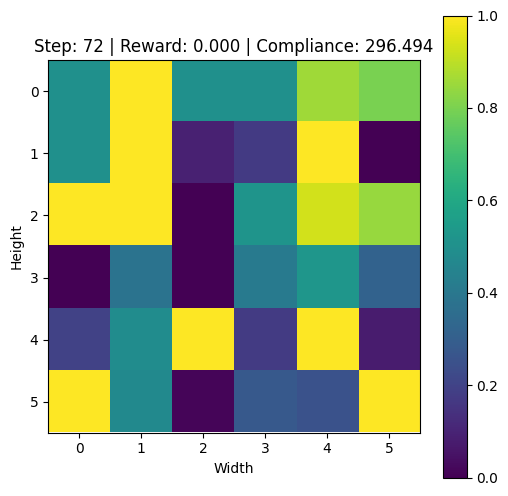

Episode: 2 	 Reward: -26.97
Episode 3: Compliance: 120.03154927857432 | Constraint: 0.49528783559799194


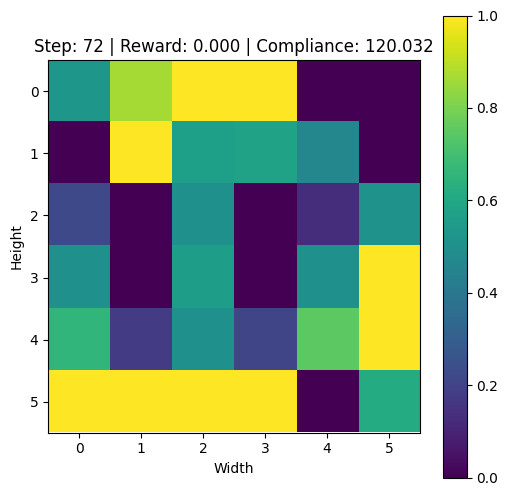

Episode: 3 	 Reward: -33.07
Episode 4: Compliance: 152.0133093672089 | Constraint: 0.4948742091655731


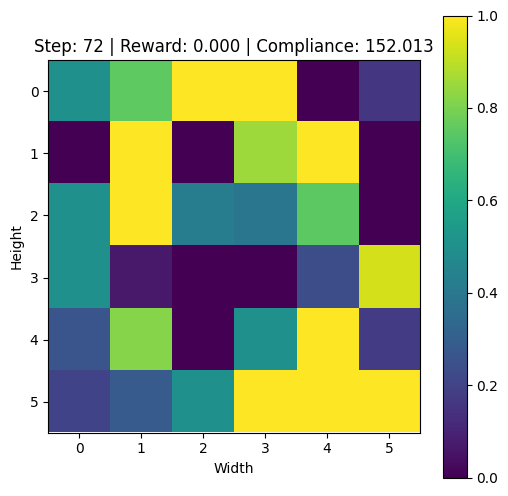

Episode: 4 	 Reward: -21.96
Episode 5: Compliance: 77.86561586685211 | Constraint: 0.5013340711593628


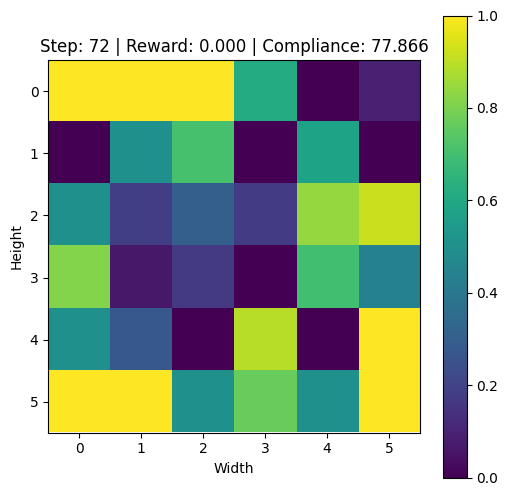

Episode: 5 	 Reward: -18.21
Episode 6: Compliance: 331.72020948070735 | Constraint: 0.4550077021121979


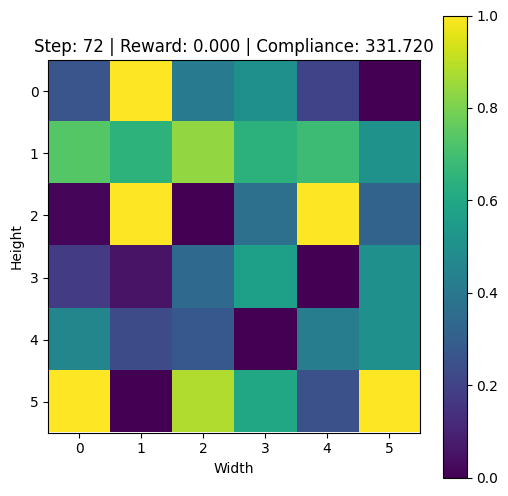

Episode: 6 	 Reward: -39.5
Episode 7: Compliance: 148.92436132313958 | Constraint: 0.4610454738140106


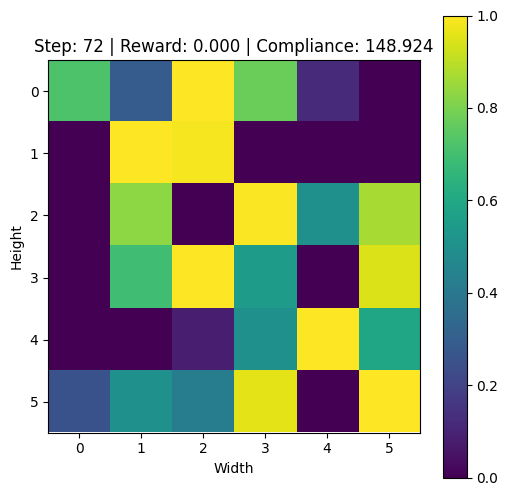

Episode: 7 	 Reward: -22.6
Episode 8: Compliance: 94.35162881998535 | Constraint: 0.5339753031730652


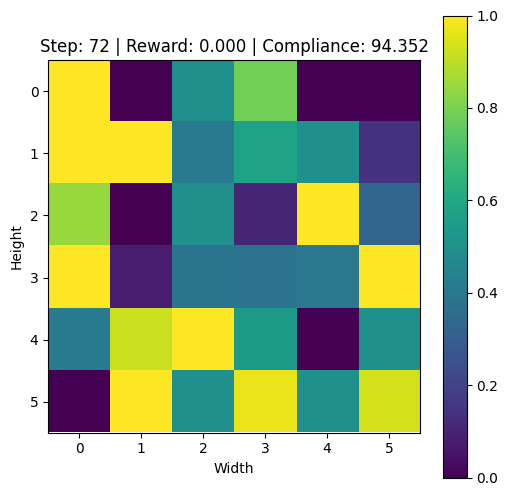

Episode: 8 	 Reward: -22.14
Episode 9: Compliance: 93.12275808143679 | Constraint: 0.48401159048080444


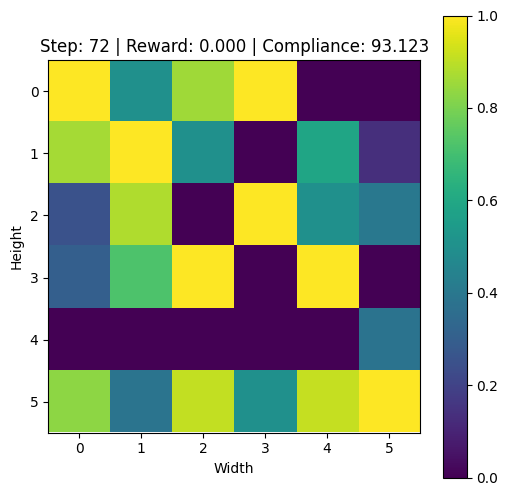

Episode: 9 	 Reward: -20.33
Episode 10: Compliance: 255.83311113772672 | Constraint: 0.45188501477241516


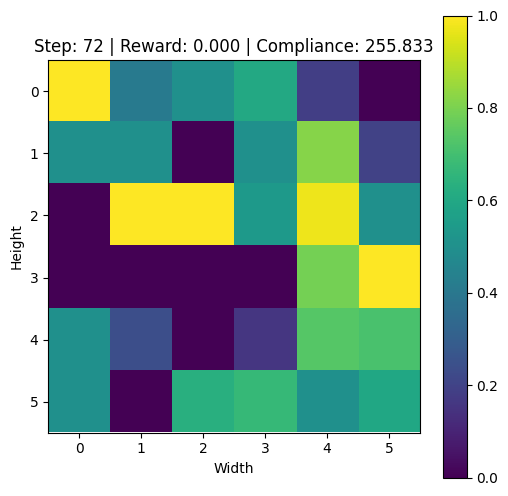

Episode: 10 	 Reward: -26.62
Average test reward: -25.51


In [5]:
# -------------------------
# Inference Hyperparameters
# -------------------------
env_name = "BeamOptimizationEnv"
has_continuous_action_space = False
total_inference_episodes = 10  # Number of episodes for testing

# (These hyperparameters are only used if you want to re-instantiate the agent.
# They must match those used during training.)
gamma = 0.95
K_epochs = 3
eps_clip = 0.3
lr_actor = 0.0003
lr_critic = 0.001

# Create a single environment instance for testing.
env = mbb_cnn.BeamOptimizationEnv(width=6, height=6, beam_type=1, optimal_density=0.5, density=0.4)
max_ep_len = env.max_steps

# Get the state and action dimensions.
# Our environment returns a 5-channel image of shape (5, 7, 7), so flattened state_dim = 5*7*7 = 245.
state_shape = env.observation_space.shape   # Expected: (5, 7, 7)
state_dim = np.prod(state_shape)              # 245

if has_continuous_action_space:
    action_dim = env.action_space.shape[0]
else:
    action_dim = env.action_space.n           # For discrete, e.g., 72
print(f"State dim: {state_dim}")
print(f"Action dim: {action_dim}")

# Set device.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Instantiate the PPO agent.
# For our CNN-based agent, we set grid_channels=5, grid_height=7, grid_width=7.
ppo_agent = ppo_cnn.PPO(
    state_dim=state_dim,
    action_dim=action_dim,
    lr_actor=lr_actor,
    lr_critic=lr_critic,
    gamma=gamma,
    K_epochs=K_epochs,
    eps_clip=eps_clip,
    has_continuous_action_space=has_continuous_action_space,
    action_std_init=0.6,
    gae_lambda=0.95,
    num_envs=1,  # Single environment for inference.
    device=device,
    grid_channels=5,
    grid_height=7,
    grid_width=7
)

# Specify checkpoint path and load weights.
random_seed = 0
run_num_pretrained = 0
checkpoint_path = f"PPO_preTrained/{env_name}/PPO_{env_name}_{random_seed}_{run_num_pretrained}.pth"
print("Loading network from:", checkpoint_path)
ppo_agent.load(checkpoint_path)
print("--------------------------------------------------------------------------------------------")

# -------------------------
# Inference Loop
# -------------------------
test_running_reward = 0.0

for ep in range(1, total_inference_episodes + 1):
    # Reset environment.
    state, _ = env.reset()
    # Flatten the state: original shape is (5, 7, 7) → (245,)
    state_flat = state.flatten()
    ep_reward = 0.0
    for t in range(1, max_ep_len + 1):
        # ppo_agent.select_action expects input shape [batch, state_dim]
        action, _, _ = ppo_agent.select_action(state_flat[None, :])
        # Since the agent returns a batch, take the first element.
        action = action[0]
        state, reward, done, truncated, info = env.step(action)
        ep_reward += reward

        # Flatten new state.
        state_flat = state.flatten()

        if done:
            print(f"Episode {ep}: Compliance: {info['compliance']} | Constraint: {info['constraint']}")
            env.render()  # Render current state.
            break

    test_running_reward += ep_reward
    print(f"Episode: {ep} \t Reward: {round(ep_reward, 2)}")

avg_test_reward = test_running_reward / total_inference_episodes
print("============================================================================================")
print(f"Average test reward: {avg_test_reward:.2f}")
print("============================================================================================")

env.close()
